In [94]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


In [95]:
# import data
df=pd.read_csv("netflix_titles.csv")
print (f"columns\t: {df.shape[1]}\nrows\t: {df.shape[0]}")


columns	: 12
rows	: 8807


In [96]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [98]:
# Clean columns
totalColumn=len(df.columns.tolist())


In [99]:
# change null data
df['director']=df['director'].fillna("tidak tertera")
df['cast']=df['cast'].fillna('tidak tertera')
df['country']=df['country'].fillna('tidak tertera')

In [100]:
# Assumstion null data is most data
count=Counter(df['date_added'])
new_data=count.most_common(1)[0][0]
df['date_added']=df['date_added'].fillna(new_data)

count=Counter(df['rating'])
new=count.most_common(1)[0][0]
df['rating']=df['rating'].fillna(new)

count =Counter(df['duration'])
new=count.most_common(1)[0][0]
df['duration']=df['duration'].fillna(new)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [102]:
df['year']=df['date_added'].str.split(',').str[1]
df['datemonth']=df['date_added'].str.split(',').str[0]
df['date']=df['datemonth'].str.split(' ').str[1]
df['month']=df['datemonth'].str.split(' ').str[0]


In [103]:
df["month"].unique().tolist()
count=Counter (df['month'])
most=count.most_common(1)[0][0]
most
df['month']=df['month'].replace(' ',most)

In [104]:
change ={
'September':9,
 'August':8,
 'July':7,
 'June':6,
 'May':5,
 'April':4,
 'March':3,
 'February':2,
 'January':1,
 'December':12,
 'November':11,
 'October':10
}
df['month']=df['month'].replace(change)

In [105]:
len(df['date'])
df['date']=df['date'].replace(' ','12')

In [106]:
# date data
df['month']=df['month'].astype(str)
df['date_added']=df['year']+'-'+df["month"]+'-'+df['date']
df['date_added']=df['date_added'].replace("--","-")
df['date_added'].head()

0     2021-9-25
1     2021-9-24
2     2021-9-24
3     2021-9-24
4     2021-9-24
Name: date_added, dtype: object

In [107]:
df['date_added'] = (
    df['date_added']
    .astype(str)
    .str.strip()                 # buang spasi depan–belakang
    .str.replace(r'\s+', ' ', regex=True)  # rapihin spasi
    .str.replace('--', '-', regex=False)   # double dash
)
df['date_added'] = pd.to_datetime(
    df['date_added'],
    format='mixed',
    errors='coerce'
)

df['date_added']=pd.to_datetime(df['date_added'])

In [108]:
df['date_added'].head ()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year          8807 non-null   object        
 13  datemonth     8807 non-null   object        
 14  date          8807 non-null   object        
 15  month         8807 non-null   object  

In [110]:
df['release_year'].head()

0    2020
1    2021
2    2021
3    2021
4    2021
Name: release_year, dtype: int64

In [111]:
indx=df['release_year']>df['date_added'].dt.year
index_ =df.index[indx].tolist()
for dex in index_:
    future=df.loc[dex,"date_added"]
    future=str(future).split('-')
    newY=df.loc[dex,'release_year'].astype (str)
    month=future[1]
    date=future[2]
    Newdate=newY+'-'+month+'-'+date
    Newdate=pd.to_datetime(Newdate)
    df.loc[dex,'date_added']=Newdate
    
    

In [112]:
df.loc [indx,:]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year,datemonth,date,month
1551,s1552,TV Show,Hilda,tidak tertera,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States",2021-12-14,2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend...",2020,December 14,14,12
1696,s1697,TV Show,Polly Pocket,tidak tertera,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland",2021-11-15,2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...,2020,November 15,15,11
2920,s2921,TV Show,Love Is Blind,tidak tertera,"Nick Lachey, Vanessa Lachey",United States,2021-02-13,2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...,2020,February 13,13,2
3168,s3169,TV Show,Fuller House,tidak tertera,"Candace Cameron Bure, Jodie Sweetin, Andrea Ba...",United States,2020-12-06,2020,TV-PG,5 Seasons,TV Comedies,The Tanner family’s adventures continue as DJ ...,2019,December 6,6,12
3287,s3288,TV Show,Maradona in Mexico,tidak tertera,Diego Armando Maradona,"Argentina, United States, Mexico",2020-11-13,2020,TV-MA,1 Season,"Docuseries, Spanish-Language TV Shows","In this docuseries, soccer great Diego Maradon...",2019,November 13,13,11
3369,s3370,TV Show,BoJack Horseman,tidak tertera,"Will Arnett, Aaron Paul, Amy Sedaris, Alison B...",United States,2020-10-25,2020,TV-MA,6 Seasons,TV Comedies,Meet the most beloved sitcom horse of the '90s...,2019,October 25,25,10
3433,s3434,TV Show,The Hook Up Plan,tidak tertera,"Marc Ruchmann, Zita Hanrot, Sabrina Ouazani, J...",France,2020-10-11,2020,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...","When Parisian Elsa gets hung up on her ex, her...",2019,October 11,11,10
4844,s4845,TV Show,Unbreakable Kimmy Schmidt,tidak tertera,"Ellie Kemper, Jane Krakowski, Tituss Burgess, ...",United States,2019-05-30,2019,TV-14,4 Seasons,TV Comedies,When a woman is rescued from a doomsday cult a...,2018,May 30,30,5
4845,s4846,TV Show,Arrested Development,tidak tertera,"Jason Bateman, Portia de Rossi, Will Arnett, M...",United States,2019-05-29,2019,TV-MA,5 Seasons,TV Comedies,It's the Emmy-winning story of a wealthy famil...,2018,May 29,29,5
5394,s5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,2018-07-01,2018,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...,2017,July 1,1,7


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  year          8807 non-null   object        
 13  datemonth     8807 non-null   object        
 14  date          8807 non-null   object        
 15  month         8807 non-null   object  

In [114]:
df.drop(['year','datemonth','date','month'],axis=1,inplace=True)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [116]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,tidak tertera,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,tidak tertera,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",tidak tertera,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,tidak tertera,tidak tertera,tidak tertera,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,tidak tertera,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [117]:
# Data Analyst
df_=df[:]
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [118]:
# realize film
year =df['release_year'].tolist()
count=Counter(year)
print(count)
x=count.keys()
y=count.values()
years=pd.DataFrame({
    'ket':x,
    'values':y
})


Counter({2018: 1147, 2017: 1032, 2019: 1030, 2020: 953, 2016: 902, 2021: 592, 2015: 560, 2014: 352, 2013: 288, 2012: 237, 2010: 194, 2011: 185, 2009: 152, 2008: 136, 2006: 96, 2007: 88, 2005: 80, 2004: 64, 2003: 61, 2002: 51, 2001: 45, 1999: 39, 1997: 38, 2000: 37, 1998: 36, 1993: 28, 1995: 25, 1996: 24, 1992: 23, 1994: 22, 1990: 22, 1988: 18, 1982: 17, 1991: 17, 1989: 16, 1986: 13, 1981: 13, 1984: 12, 1983: 11, 1980: 11, 1979: 11, 1985: 10, 1973: 10, 1976: 9, 1987: 8, 1975: 7, 1978: 7, 1974: 7, 1977: 7, 1972: 5, 1971: 5, 1967: 5, 1945: 4, 1960: 4, 1958: 3, 1962: 3, 1968: 3, 1955: 3, 1944: 3, 1943: 3, 1964: 2, 1954: 2, 1956: 2, 1963: 2, 1970: 2, 1969: 2, 1965: 2, 1946: 2, 1942: 2, 1961: 1, 1959: 1, 1925: 1, 1966: 1, 1947: 1})


Text(0, 0.5, 'Count of Film')

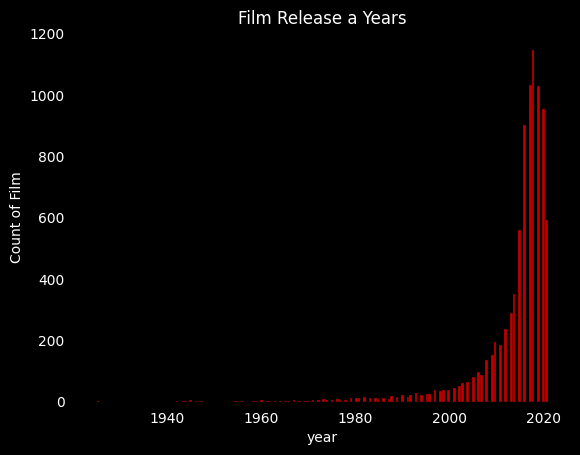

In [119]:
plt.figure(facecolor='black')
graph =sns.histplot(data=df_,x='release_year',color='red')
graph.set_facecolor('black')
plt.title('Film Release a Years',color='white')
sns.despine(right=True, top=True)
plt.xticks(color="white")
plt.yticks(color="white")
plt.xlabel("year",color='white')
plt.ylabel('Count of Film',color='white')



In [120]:
# Total Film added in Netflix

# minimum film added
year =df_["date_added"].dt.year.tolist()
max_=np.max(year)
min_=np.min(year)
total=len(year)
print (f"From {min_} to {max_}, Netflix added {total} film of the apps")

From 2008 to 2021, Netflix added 8807 film of the apps


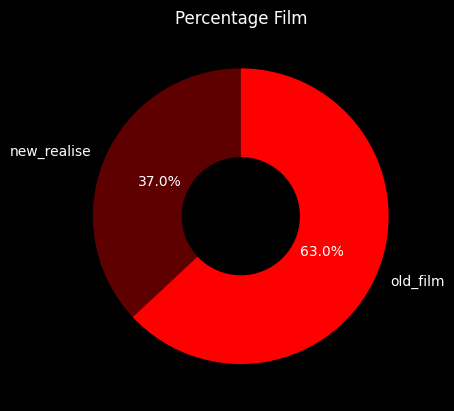

In [121]:
same_realese=(df['release_year']==df['date_added'].dt.year)
tot_same_=len(df.loc[same_realese,'release_year'].tolist())
tot_same_
tot_old_=total-tot_same_
columns=['new_realise','old_film']
values=[tot_same_,tot_old_]
color=['#5f0000','red']
plt.figure(facecolor='black')
plt.pie(values,labels=columns, autopct='%1.1f%%',textprops={"color":'white'},startangle=90,colors=color)
circle=plt.Circle((0,0),0.40,fc='black')
plt.gca().add_artist(circle)
plt.title("Percentage Film",color='white')
plt.show()

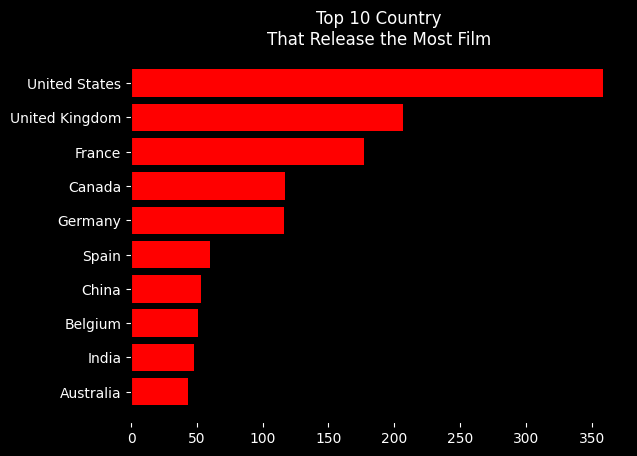

In [126]:
# data country 
count =Counter(df_['country'].unique().tolist())

country=[]
for i in count:
    i=str(i)
    j=i.split(',')
    count =len(j)
    for k in range(count):
       country.append(j[k])

country =[i.strip() for i in country]
count=Counter(country)
most_5=count.most_common(10)

df_tot=pd.DataFrame({
    'country':[most_5[i][0] for i in range(len(most_5))],
    'total':[most_5[i][1] for i in range(len(most_5))]
})
df_tot=df_tot.sort_values(by='total')
plt.figure(facecolor="black")
plt.gca().set_facecolor("black")
graph =plt.barh(df_tot['country'],df_tot['total'],color='red')
plt.tick_params(axis ='x',colors='white')
plt.tick_params(axis ='y',colors='white')
plt.title("Top 10 Country\nThat Release the Most Film", color= 'white')
plt.show()


Counter({7: 827, 12: 813, 9: 770, 4: 764, 10: 760, 8: 755, 1: 748, 3: 742, 6: 728, 11: 705, 5: 632, 2: 563})


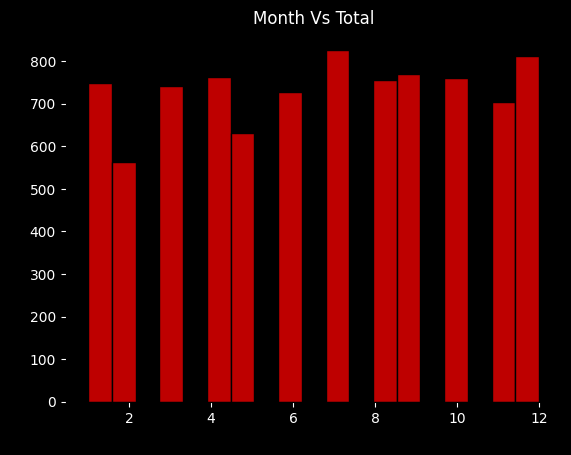

In [123]:
# Bulan /banyak film
month =df['date_added'].dt.month.tolist()
count =Counter(month)
print (count)
df_month=pd.DataFrame({
    'month':month
})
plt.figure(facecolor='black')
graph=sns.histplot(data=df_month,x ='month',color='red')
graph.set_facecolor('black')
plt.tick_params(axis ='x',colors='white')
plt.tick_params(axis ='y',colors='white')
plt.title("Month Vs Total", color= 'white')
plt.show()
